#Dissertation:

##Preprocessing:

In [43]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sn
from lightgbm import LGBMRegressor
import seaborn as sns
import shap
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
# Imported neccessary libraries for the models, EDA, Clustering

#Loaded the dataset in
df = pd.read_csv('/content/drive/MyDrive/Dissertation/Chicago_Energy_Benchmarking.csv')

#Showed the first few rows of the data
print(df.head())

# Checked the data types and looked for any missing values
print(df.info())

#Dropped columns that are non-predcitve like Address
drop_cols = [
    'Chicago Energy Rating', 'Exempt From Chicago Energy Rating',
    'Data Year', 'Address', 'Location',
    'Historical Energy Use (kBtu)', 'ENERGY STAR Certification - Year(s)'
]
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

#Removed rows with no energy star score
df = df.dropna(subset=['ENERGY STAR Score'])

#Used median for numerical columns and mode for the categorical columns
for col in df.columns:
    if df[col].dtype in [np.float64, np.int64]:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
#Text columns were turned into a numerical format for machine learning models
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop('ENERGY STAR Score', axis=1)
y = df['ENERGY STAR Score']

   Data Year      ID              Property Name Reporting Status  \
0       2020  252064           Mansueto Library   Submitted Data   
1       2020  232458  Harper Square Cooperative   Submitted Data   
2       2020  254616       Former Coyne College   Submitted Data   
3       2020  103812          400 W Superior St   Submitted Data   
4       2020  254073            Blue Moon Lofts   Submitted Data   

                       Address ZIP Code  Chicago Energy Rating  \
0               1100 E 57th St    60637                    2.0   
1  4800 - 4850 S Lake Park Ave    60615                    1.0   
2               330 N Green St    60607                    2.0   
3            400 W Superior St    60654                    3.0   
4          215 N. Aberdeen St.    60607                    4.0   

  Exempt From Chicago Energy Rating   Community Area Primary Property Type  \
0                             False        HYDE PARK               Library   
1                             False   

In [45]:
#The features were normailsed by removing mean and sclaing to the unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("\nData Preprocessing Complete.")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Data Preprocessing Complete.
Train shape: (13908, 24), Test shape: (3478, 24)



##EDA:

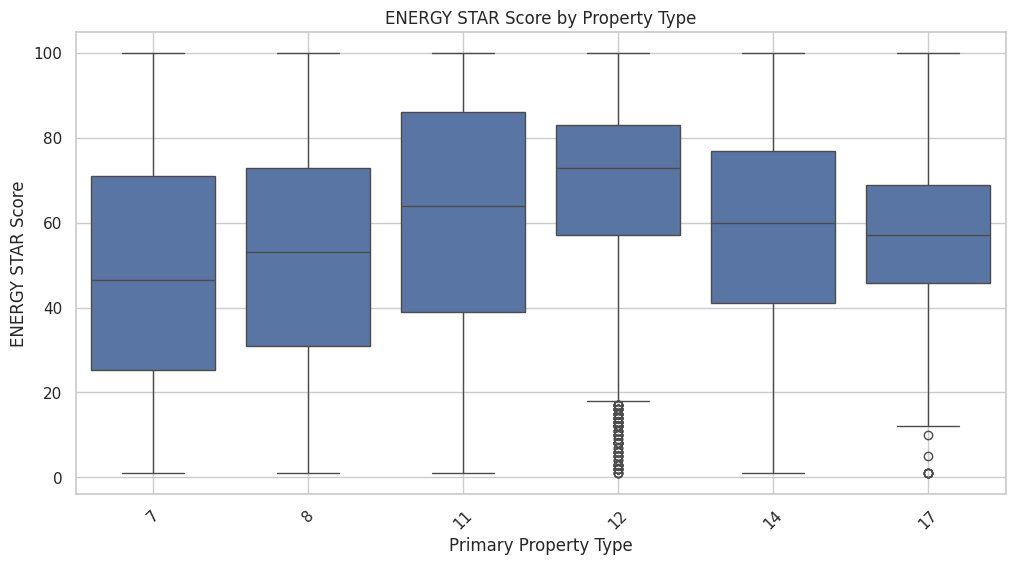

In [46]:
#Reduced the focus to th top 6 most frequent building types
top_types = df['Primary Property Type'].value_counts().head(6).index
filtered_df = df[df['Primary Property Type'].isin(top_types)]

#Visulaised this using a boxplot to show interquaritle range, outliers and medians
plt.figure(figsize=(12,6))
sns.boxplot(data=filtered_df, x='Primary Property Type', y='ENERGY STAR Score')
plt.title('ENERGY STAR Score by Property Type')
plt.ylabel('ENERGY STAR Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


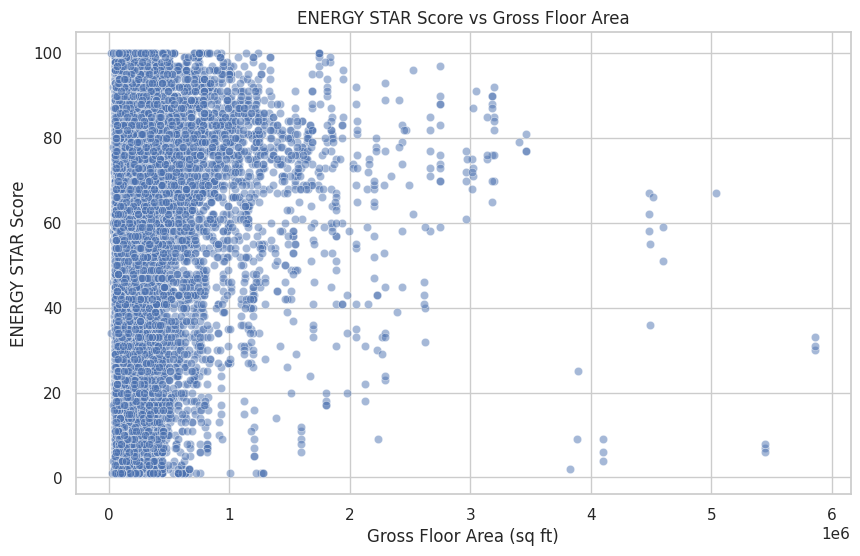

In [47]:
plt.figure(figsize=(10,6))
#Showed the building size associated with energy efficinecy
sns.scatterplot(data=df, x='Gross Floor Area - Buildings (sq ft)', y='ENERGY STAR Score', alpha=0.5)
plt.title('ENERGY STAR Score vs Gross Floor Area')
plt.xlabel('Gross Floor Area (sq ft)')
plt.ylabel('ENERGY STAR Score')
plt.grid(True)
plt.show()


                  ID  Property Name  Reporting Status      ZIP Code  \
count   17386.000000   17386.000000      17386.000000  17386.000000   
mean   186086.458817    2722.191361          2.272978     47.846658   
std     60547.367161    1553.738622          0.449487     24.574332   
min    100001.000000       0.000000          0.000000      0.000000   
25%    119685.000000    1341.000000          2.000000     28.000000   
50%    173870.000000    2748.000000          2.000000     40.000000   
75%    251439.000000    4133.000000          3.000000     71.000000   
max    260184.000000    5048.000000          3.000000     96.000000   

       Community Area  Primary Property Type  \
count    17386.000000            17386.00000   
mean        65.624525               10.79587   
std         25.417620                2.12744   
min          0.000000                0.00000   
25%         56.000000               11.00000   
50%         72.000000               11.00000   
75%         74.000000   

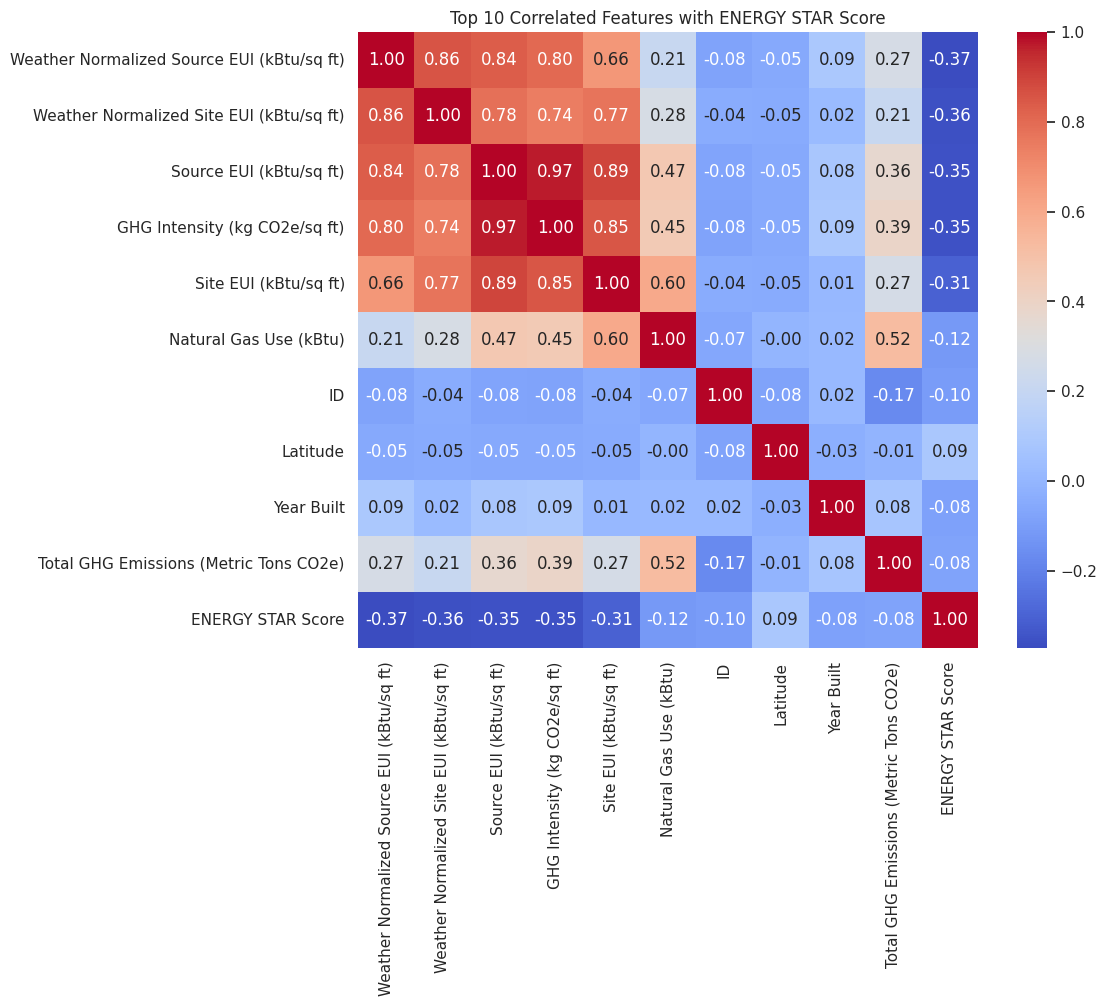

In [48]:
sns.set(style="whitegrid")
#Adds a clear grid background for the grpahs

#Showed the descriptive stats for all numerical features
print(df.describe())

target_corr = df.corr()["ENERGY STAR Score"].drop("ENERGY STAR Score")
top_corr_features = target_corr.abs().sort_values(ascending=False).head(10).index.tolist()

#Showed the ENERGY STAR Score to show the corelation
heatmap_features = top_corr_features + ["ENERGY STAR Score"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[heatmap_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 Correlated Features with ENERGY STAR Score")
plt.show()
#Heatmap makes it easier to show if the features are postievly or negatively corealated

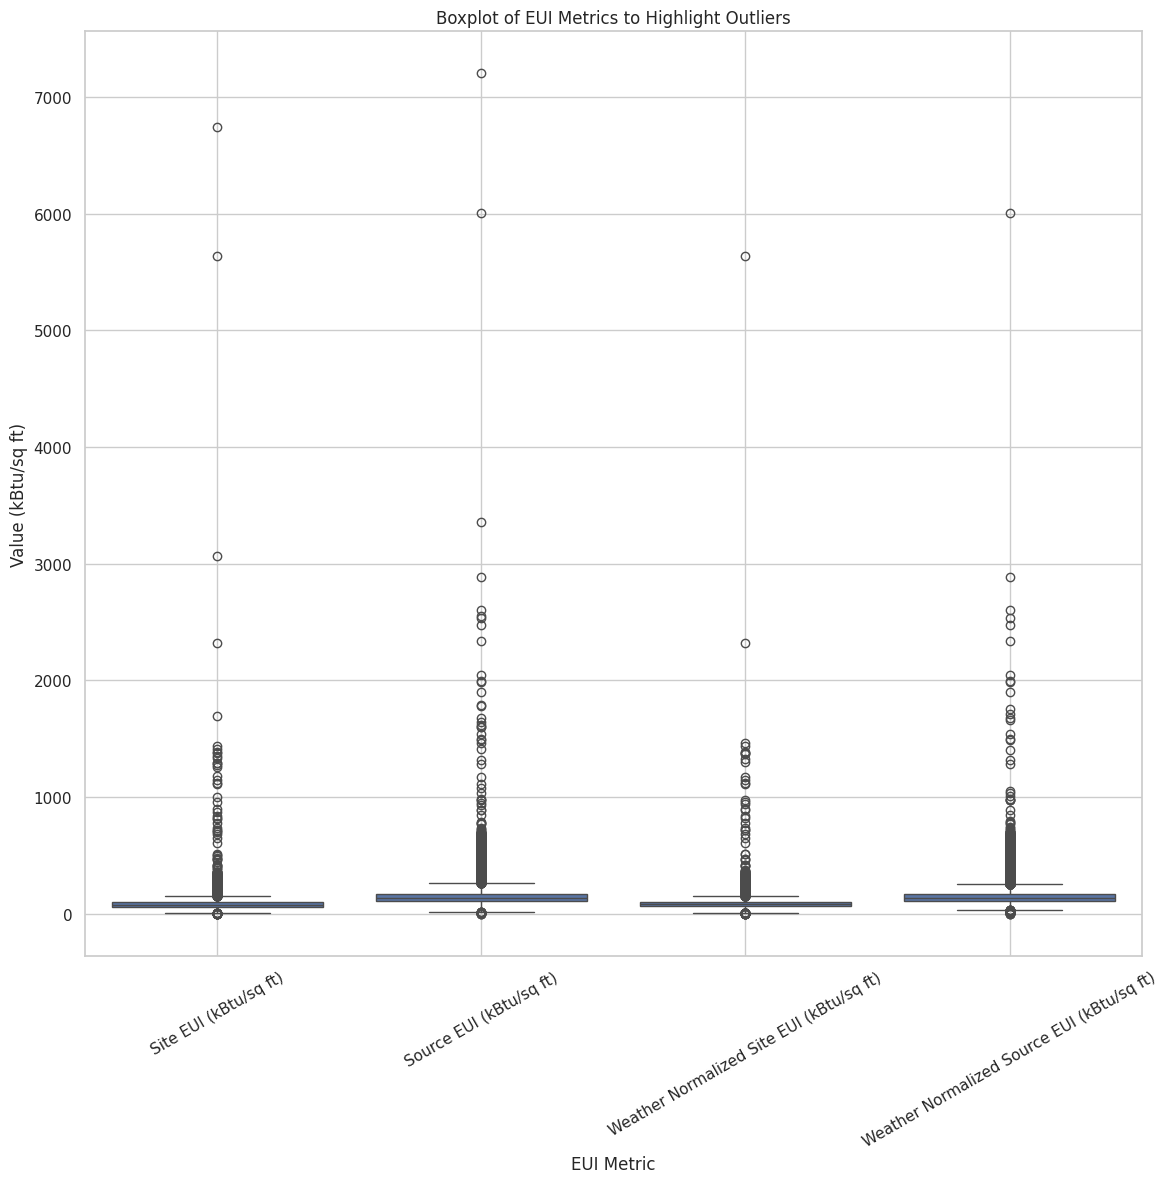

In [49]:
# Selected the key EUI columns
eui_cols = [
    'Site EUI (kBtu/sq ft)',
    'Source EUI (kBtu/sq ft)',
    'Weather Normalized Site EUI (kBtu/sq ft)',
    'Weather Normalized Source EUI (kBtu/sq ft)'
]

# Droped rows with missing values in these columns
eui_df = df[eui_cols].dropna()

eui_long = eui_df.melt(var_name="EUI Metric", value_name="Value")

# Createed a boxplot to identify outliers
plt.figure(figsize=(12, 12))
sns.boxplot(data=eui_long, x="EUI Metric", y="Value")
plt.title("Boxplot of EUI Metrics to Highlight Outliers")
plt.ylabel("Value (kBtu/sq ft)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.grid(True)
plt.show()



Top 10 correlated features with ENERGY STAR Score:
Weather Normalized Source EUI (kBtu/sq ft)   -0.372136
Weather Normalized Site EUI (kBtu/sq ft)     -0.356676
Source EUI (kBtu/sq ft)                      -0.353443
GHG Intensity (kg CO2e/sq ft)                -0.351844
Site EUI (kBtu/sq ft)                        -0.306093
Natural Gas Use (kBtu)                       -0.119612
ID                                           -0.104537
Latitude                                      0.087186
Year Built                                   -0.084528
Total GHG Emissions (Metric Tons CO2e)       -0.079332
Name: ENERGY STAR Score, dtype: float64


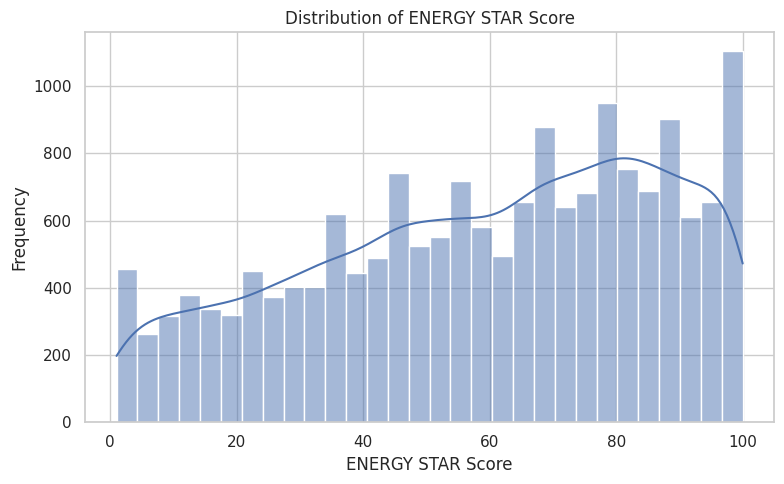

In [50]:
target_corr = df.corr()["ENERGY STAR Score"].drop("ENERGY STAR Score").sort_values(key=abs, ascending=False)
top_corr_features = target_corr.head(10)
#Got the top 10 strongest corelations
print("\nTop 10 correlated features with ENERGY STAR Score:")
print(top_corr_features)

categorical_cols = list(label_encoders.keys())
selected_cats = categorical_cols[:3]
#Previews the first 3 encoded categories

plt.figure(figsize=(8, 5))
sns.histplot(df["ENERGY STAR Score"], bins=30, kde=True)
plt.title("Distribution of ENERGY STAR Score")
plt.xlabel("ENERGY STAR Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
#Histogram showed to show the distribution

top_features = top_corr_features.head(3).index.tolist()
pairplot_df = df[top_features + ["ENERGY STAR Score"]]

##Predictive Modeling:

In [51]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
#Calculated the regression metrics for the models
    print(f"{name} Performance:")
    print(f"MAE:  {mae:}")
    print(f"MSE:  {mse:}")
    print(f"RMSE: {rmse:}")
    print(f"R²:   {r2:}")
    print("-" * 40)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}
#Prints the performance of the models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "SVR": SVR(kernel='rbf', C=10, epsilon=0.1)
}

results = []
#Trained and evaluated models
for name, model in models.items():
    model.fit(X_train, y_train)
    res = evaluate_model(name, model, X_test, y_test)
    results.append(res)

base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('svr', SVR(kernel='rbf', C=10, epsilon=0.1))
]

stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)
#Used meta regrossor and other models as base learners
stacking_model.fit(X_train, y_train)
res = evaluate_model("Stacking Ensemble", stacking_model, X_test, y_test)
results.append(res)

Linear Regression Performance:
MAE:  20.381059148713522
MSE:  595.6982766905486
RMSE: 24.406930915019785
R²:   0.20999425070164923
----------------------------------------
Ridge Regression Performance:
MAE:  20.381205167723472
MSE:  595.7001569659016
RMSE: 24.40696943428048
R²:   0.20999175710984752
----------------------------------------
Random Forest Performance:
MAE:  7.274985623921794
MSE:  104.29136060954572
RMSE: 10.212314165239224
R²:   0.8616904266679812
----------------------------------------
XGBoost Performance:
MAE:  7.822149576101926
MSE:  118.10433514054206
RMSE: 10.867581844207205
R²:   0.8433718756138752
----------------------------------------
SVR Performance:
MAE:  11.243554705182413
MSE:  231.92185018135186
RMSE: 15.228980602172683
R²:   0.6924288650807076
----------------------------------------
Stacking Ensemble Performance:
MAE:  7.114921823525737
MSE:  102.1001371381997
RMSE: 10.104461249279929
R²:   0.8645963930071454
----------------------------------------


<ipython-input-52-c0392d4ba023>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", palette="Blues_d")


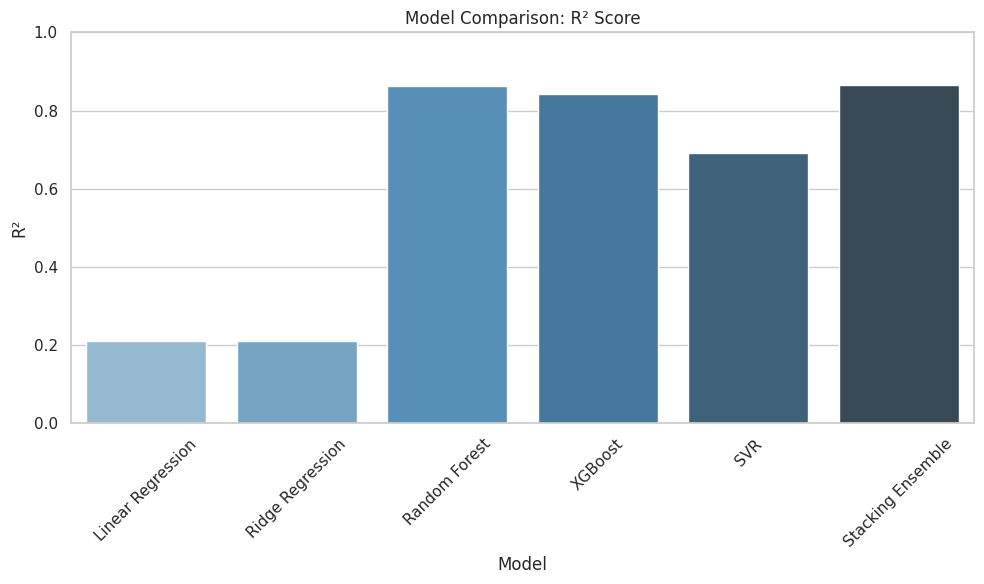

<ipython-input-52-c0392d4ba023>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", palette="Reds_d")


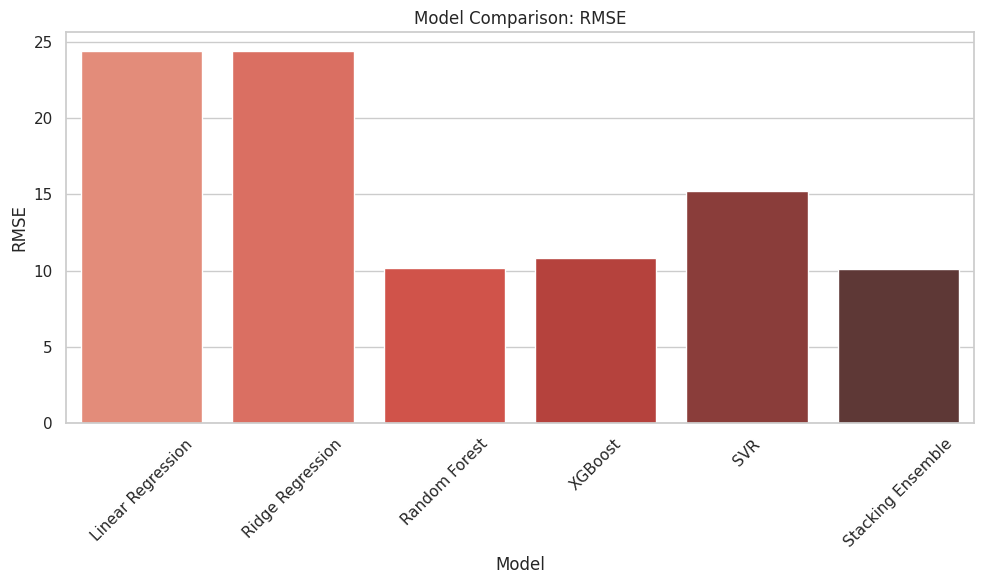

In [52]:
results_df = pd.DataFrame(results)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="R2", palette="Blues_d")
plt.title("Model Comparison: R² Score")
plt.ylim(0, 1)
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#Used a histogram to show all of the results compared to one another for the R²
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="RMSE", palette="Reds_d")
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#Used a histogram to show all of the results compared to one another for the RMSE

##SHAP:

 95%|=================== | 3319/3478 [00:21<00:01]       

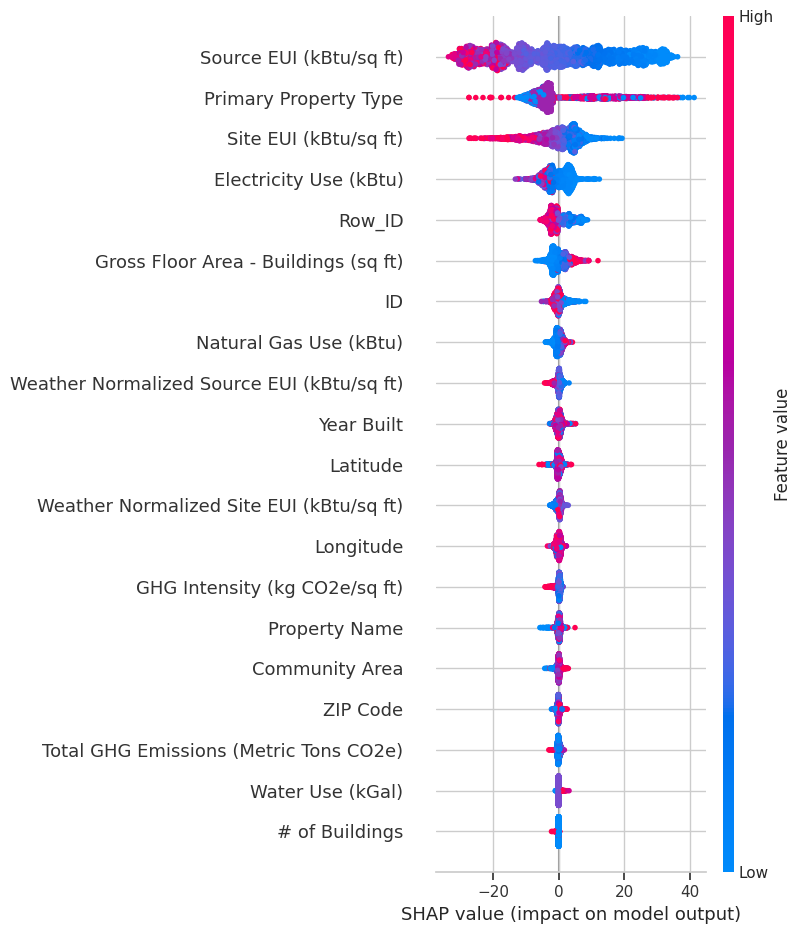

In [53]:
best_model = models["XGBoost"]

best_model.fit(X_train, y_train)
#SHAP explainer based on a fully trained model
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, features=X_test, feature_names=X.columns)
#Interpreted which features are most influential in the model's decisions

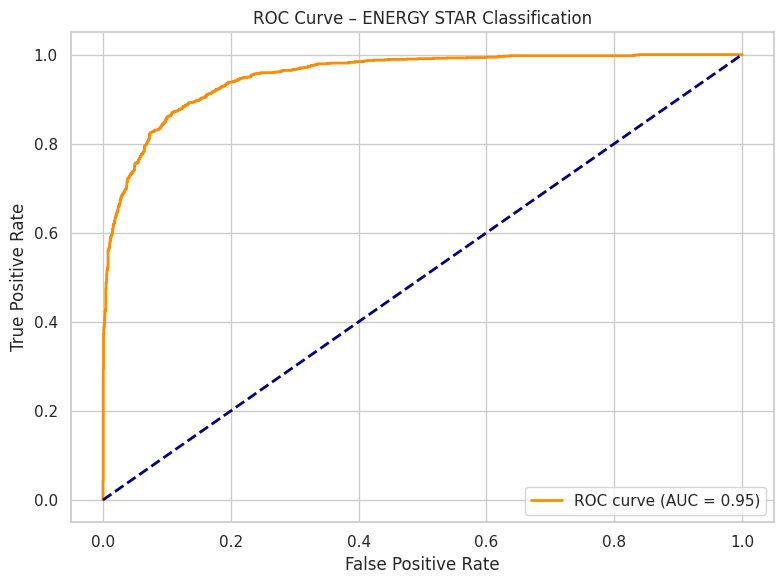

In [54]:
# Choose the XGBoost model for this
best_model = models["XGBoost"]

# Predicted the ENERGY STAR Scores
y_pred_scores = best_model.predict(X_test)

# Turned actual ENERGY STAR scores to binary where 1 is efficient and 0 is efficient
threshold = 75
y_binary = (y_test >= threshold).astype(int)

# Computed ROC metrics
fpr, tpr, thresholds = roc_curve(y_binary, y_pred_scores)
roc_auc = roc_auc_score(y_binary, y_pred_scores)

# Ploted ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – ENERGY STAR Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


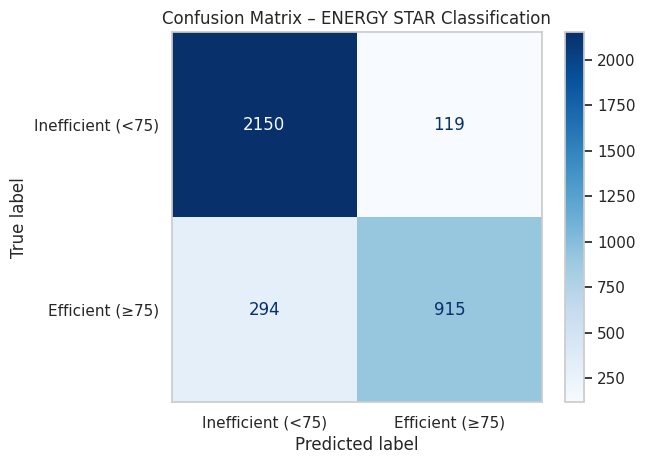

In [55]:
y_pred_scores = best_model.predict(X_test)

y_pred_binary = (y_pred_scores >= threshold).astype(int)
y_true_binary = (y_test >= threshold).astype(int)

#Generated the confusion matrix
cm = confusion_matrix(y_true_binary, y_pred_binary)

#Ploted a confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inefficient (<75)', 'Efficient (≥75)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – ENERGY STAR Classification')
plt.grid(False)
plt.tight_layout()
plt.show()


##Clustering:

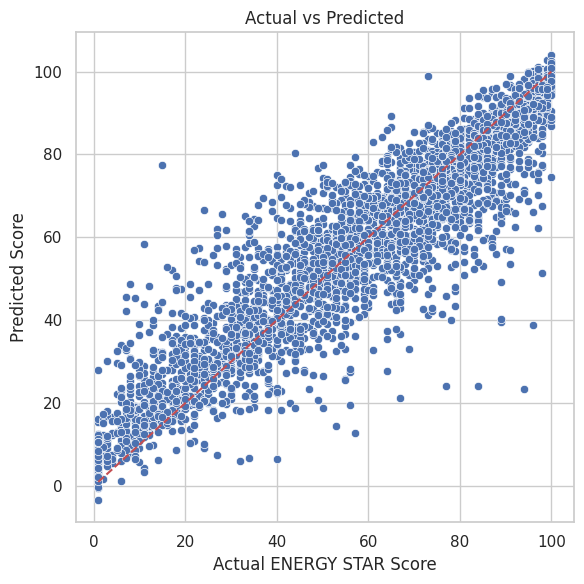

In [56]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=best_model.predict(X_test))
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual ENERGY STAR Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
#Plotted the actual scores vs the predicted scores
plt.tight_layout()
plt.show()

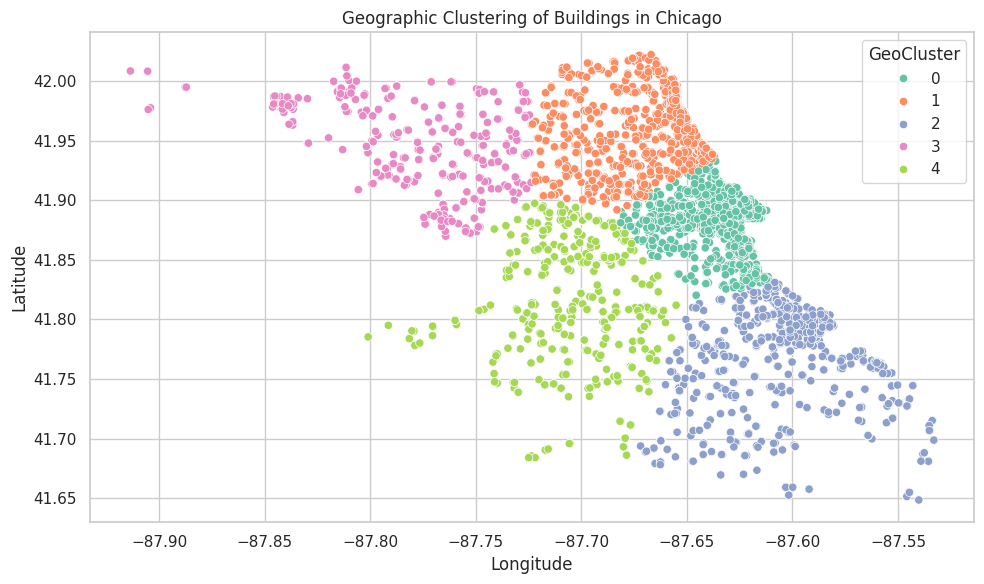

In [57]:
geo_df = df.dropna(subset=['Latitude', 'Longitude']).copy()
#Remove rows with missing lattitude and longitude
coords_scaled = StandardScaler().fit_transform(geo_df[['Latitude', 'Longitude']])

kmeans = KMeans(n_clusters=5, random_state=42)
geo_df['GeoCluster'] = kmeans.fit_predict(coords_scaled)
#grouped the buildings into spatial clusters based on location
plt.figure(figsize=(10, 6))
sns.scatterplot(data=geo_df, x='Longitude', y='Latitude', hue='GeoCluster', palette='Set2')
plt.title("Geographic Clustering of Buildings in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

   GeoCluster  ENERGY STAR Score  Site EUI (kBtu/sq ft)  \
0           0              58.86                  83.74   
1           1              61.97                  87.52   
2           2              54.55                 101.97   
3           3              58.01                  95.93   
4           4              53.68                  97.84   

   Total GHG Emissions (Metric Tons CO2e)  SustainabilityIndex  
0                                 3838.45                 0.92  
1                                 1270.55                 1.07  
2                                 1387.64                 1.01  
3                                 1673.10                 1.02  
4                                 1276.17                 1.03  


<ipython-input-58-8baf82e01b4a>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='ENERGY STAR Score', palette='Set2')


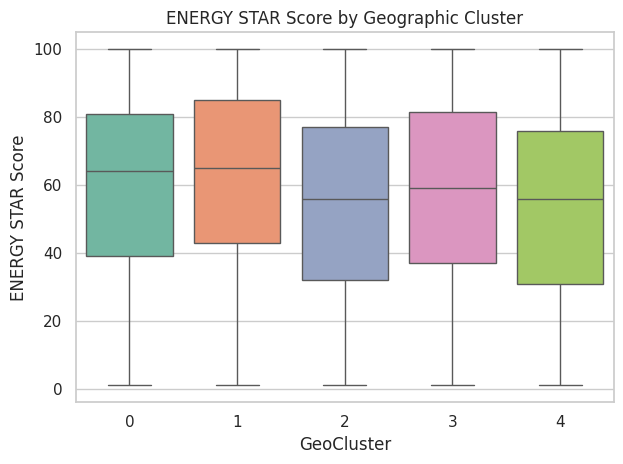

<ipython-input-58-8baf82e01b4a>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='Site EUI (kBtu/sq ft)', palette='Set2')


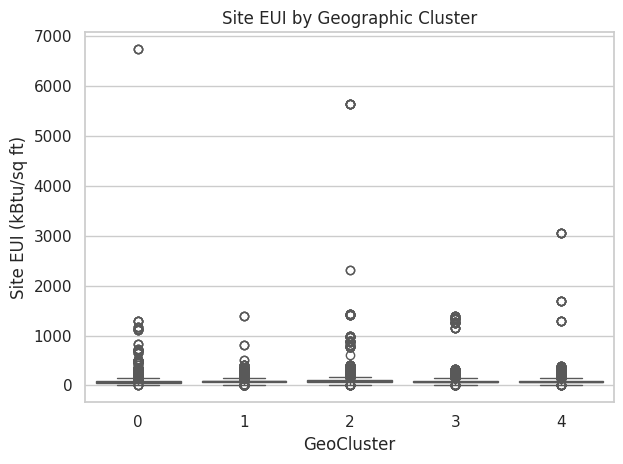

<ipython-input-58-8baf82e01b4a>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='Total GHG Emissions (Metric Tons CO2e)', palette='Set2')


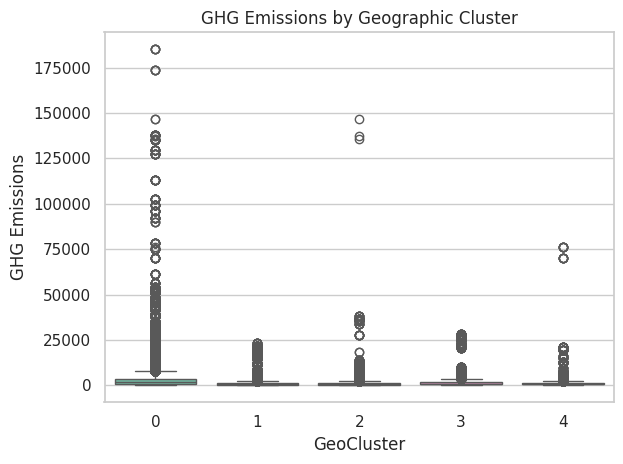

<ipython-input-58-8baf82e01b4a>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='SustainabilityIndex', palette='Set2')


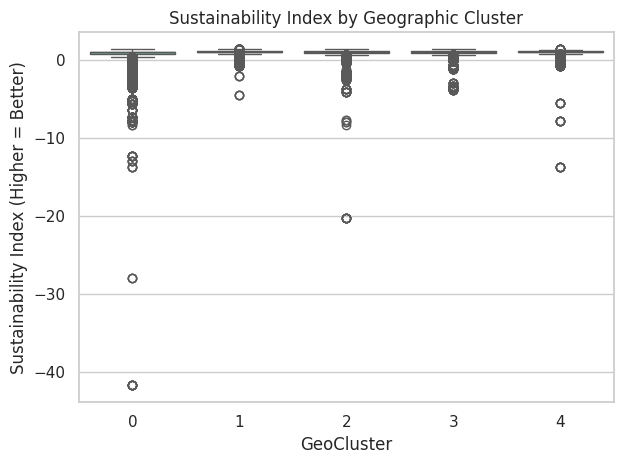

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_analysis_df = df_filtered.merge(geo_df[['ID', 'GeoCluster']], on='ID')

cluster_summary = cluster_analysis_df.groupby('GeoCluster')[
    ['ENERGY STAR Score', 'Site EUI (kBtu/sq ft)',
     'Total GHG Emissions (Metric Tons CO2e)', 'SustainabilityIndex']
].mean().round(2).reset_index()

print(cluster_summary)

sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='ENERGY STAR Score', palette='Set2')
plt.title("ENERGY STAR Score by Geographic Cluster")
plt.xlabel("GeoCluster")
plt.ylabel("ENERGY STAR Score")
plt.tight_layout()
plt.show()

sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='Site EUI (kBtu/sq ft)', palette='Set2')
plt.title("Site EUI by Geographic Cluster")
plt.xlabel("GeoCluster")
plt.ylabel("Site EUI (kBtu/sq ft)")
plt.tight_layout()
plt.show()

sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='Total GHG Emissions (Metric Tons CO2e)', palette='Set2')
plt.title("GHG Emissions by Geographic Cluster")
plt.xlabel("GeoCluster")
plt.ylabel("GHG Emissions")
plt.tight_layout()
plt.show()

sns.boxplot(data=cluster_analysis_df, x='GeoCluster', y='SustainabilityIndex', palette='Set2')
plt.title("Sustainability Index by Geographic Cluster")
plt.xlabel("GeoCluster")
plt.ylabel("Sustainability Index (Higher = Better)")
plt.tight_layout()
plt.show()